In [4]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.covariance import EmpiricalCovariance
from scipy.spatial.distance import mahalanobis
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load Data
!wget -O department-v2.csv https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
!wget -O linkedin-cvs-annotated.json https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/linkedin-cvs-annotated.json
df_train_raw = pd.read_csv('department-v2.csv').rename(columns={'job_description': 'text'})

# 1. Load the downloaded linkedin-cvs-annotated.json file into a pandas DataFrame named linkedin_cvs_df
linkedin_cvs_df = pd.read_json('linkedin-cvs-annotated.json')
print("Original linkedin_cvs_df loaded.")
wide_df = pd.DataFrame(linkedin_cvs_df)  # Columns: 0..36, Values: dict or None
long_df = wide_df.melt(var_name="job_col", value_name="job")
long_df = long_df[long_df["job"].notna()].copy()
df_validate = pd.json_normalize(long_df["job"])
df_validate.reset_index(drop=True, inplace=True)


# 2. Define "Other"
OOD_LABEL = 'Other'

# 3. Clean TRAINING SET (Learn In-Distribution only!)
# We remove all "Other" rows from the training set.
df_train_id = df_train_raw[df_train_raw['label'] != OOD_LABEL].copy()

# 4. Train-Test Split for ID-Data
# Here we insert the Train-Test Split
# df_train_id now contains the ID data WITHOUT 'Other'

# Split the In-Distribution data into training and test set
# We use 'stratify' to ensure the class distribution is similar in both sets.
df_train_id, df_test_id, _, _ = train_test_split(
    df_train_id, df_train_id['label'], test_size=0.2, random_state=42, stratify=df_train_id['label']
)

# OOD-Test: The "Other" cases (for checking OOD detection)
# We take 'Other' from Test AND Training (which we removed above) as OOD examples
ood_from_train = df_train_raw[df_train_raw['label'] == OOD_LABEL]
df_test_ood =  ood_from_train

print(f"Training (Clean ID): {len(df_train_id)}")
print(f"Test (Clean ID):     {len(df_test_id)}")
print(f"Test (OOD/Other):    {len(df_test_ood)}")

Using device: cuda
--2026-01-31 19:06:02--  https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/department-v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 468519 (458K) [text/plain]
Saving to: ‘department-v2.csv’

department-v2.csv   100%[===================>] 457.54K  --.-KB/s    in 0.02s   

2026-01-31 19:06:02 (21.2 MB/s) - ‘department-v2.csv’ saved [468519/468519]

--2026-01-31 19:06:02--  https://raw.githubusercontent.com/konradfuniwue/PracticalDataScience/refs/heads/main/Data/Original%20Data/linkedin-cvs-annotated.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubuse

In [6]:
# 1. filter for ACTIVE status
if 'status' in df_validate.columns:
    df_validate = df_validate[df_validate['status'] == 'ACTIVE']

# 2. Get relevant columns and rename
if 'position' in df_validate.columns and 'department' in df_validate.columns:
    df_validate = df_validate[['position', 'department']].rename(columns={'position': 'text', 'department': 'label'})
    # Reset the index after filtering to ensure it's contiguous and matches the number of rows
    df_validate.reset_index(drop=True, inplace=True)
else:
    print("Columns 'position' and 'department' not found in df_validate. Assuming transformation already occurred.")

display(df_validate.head())
df_validate.shape

,text,label
0,Prokurist,Other
1,Solutions Architect,Information Technology
2,Medizintechnik Beratung,Consulting
3,Director expansión de negocio.,Business Development
4,"APL-ansvarig, samordning",Administrative


(623, 2)

In [7]:
# 1. Load a state-of-the-art language classifier model (e.g., all-MiniLM-L6-v2)
# This model is a good general-purpose model for sentence embeddings.
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)
print(f"Loaded SentenceTransformer model: {model_name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded SentenceTransformer model: all-MiniLM-L6-v2


In [8]:
# 2. generate Embeddings for all Sets and apply normalization
print("Encoding & Normalizing Data...")
train_embeddings = normalize(model.encode(df_train_id['text'].tolist()), norm='l2')
test_id_emb      = normalize(model.encode(df_test_id['text'].tolist()), norm='l2')
test_ood_emb     = normalize(model.encode(df_test_ood['text'].tolist()), norm='l2')
val_embeddings   = normalize(model.encode(df_validate['text'].tolist()), norm='l2')

Encoding & Normalizing Data...


In [9]:
# 3. Fitting (Mahalanobis & K-Means)

unique_classes = df_train_id['label'].unique()
class_means = {}
class_sub_centroids = {}
K_SUB = 3  # Hyperparameter: Number of sub-clusters (modes) to identify per class

print("Fitting Centroids, Covariance & K-Means...")
# Covariance Matrix
cov_model = EmpiricalCovariance().fit(train_embeddings)
cov_inv = cov_model.precision_

for label in unique_classes:
    mask = (df_train_id['label'] == label).values
    emb_subset = train_embeddings[mask]

    # A) Class Mean (for Mahalanobis & Cosine)
    class_means[label] = np.mean(emb_subset, axis=0)

    # B) K-Means Sub-Centroids (for K-Means Score)
    k_actual = min(K_SUB, len(emb_subset))
    if k_actual > 0:
        kmeans = KMeans(n_clusters=k_actual, n_init=5, random_state=42)
        kmeans.fit(emb_subset)
        class_sub_centroids[label] = kmeans.cluster_centers_
    else:
        class_sub_centroids[label] = class_means[label].reshape(1, -1)

# Pre-compute Matrices to improve performance
all_kmeans_centroids = np.vstack(list(class_sub_centroids.values())) # (N_clusters, Dim)
all_class_means_matrix = np.array(list(class_means.values()))         # (N_classes, Dim)

Fitting Centroids, Covariance & K-Means...


In [10]:
# 4. Universal Scoring Function

def get_ood_scores(embeddings, method='mahalanobis'):
    """
    Calculates OOD scores.
    Methods: 'mahalanobis' (Standard), 'kmeans' (Multi-Cluster), 'cosine' (Angle)
    """
    scores = []

    if method == 'mahalanobis':
        # Uses global class_means & cov_inv
        for emb in embeddings:
            distances = []
            for label, mean in class_means.items():
                d = mahalanobis(emb, mean, cov_inv)
                distances.append(d)
            scores.append(np.min(distances))

    elif method == 'kmeans':
        # Euclidean distance to the NEAREST Sub-Cluster
        # Shape: (n_samples, n_total_centroids)
        dists = euclidean_distances(embeddings, all_kmeans_centroids)
        scores = np.min(dists, axis=1) # Min Distance = Score

    elif method == 'cosine':
        # 1 - Cosine Sim to the NEAREST Class-Mean
        sims = cosine_similarity(embeddings, all_class_means_matrix)
        max_sim = np.max(sims, axis=1)
        scores = 1 - max_sim # Reverse: 0 = ID, 1 = OOD

    return np.array(scores)

In [11]:
# 5. calculate kmeans
print(f"Scoring with method: kmeans.")
kmeans_scores_id = get_ood_scores(test_id_emb, method='kmeans')
kmeans_scores_ood = get_ood_scores(test_ood_emb, method='kmeans')
kmeans_val_scores = get_ood_scores(val_embeddings, method='kmeans')

# 6. calculate mahalanobis
print(f"Scoring with method: mahalanobis.")
mahalanobis_scores_id = get_ood_scores(test_id_emb, method='mahalanobis')
mahalanobis_scores_ood = get_ood_scores(test_ood_emb, method='mahalanobis')
mahalanobis_val_scores = get_ood_scores(val_embeddings, method='mahalanobis')

# 7. calculate cosine
print(f"Scoring with method: cosine.")
cosine_scores_id = get_ood_scores(test_id_emb, method='cosine')
cosine_scores_ood = get_ood_scores(test_ood_emb, method='cosine')
cosine_val_scores = get_ood_scores(val_embeddings, method='cosine')

# Add scores as new columns to the DataFrames
df_test_id['ood_score_cosine'] = cosine_scores_id
df_test_ood['ood_score_cosine'] = cosine_scores_ood
df_validate['ood_score_cosine'] = cosine_val_scores

df_test_id['ood_score_kmeans'] = kmeans_scores_id
df_test_ood['ood_score_kmeans'] = kmeans_scores_ood
df_validate['ood_score_kmeans'] = kmeans_val_scores

df_test_id['ood_score_mahalanobis'] = mahalanobis_scores_id
df_test_ood['ood_score_mahalanobis'] = mahalanobis_scores_ood
df_validate['ood_score_mahalanobis'] = mahalanobis_val_scores



print("Scoring Done. Cosine scores added to df_test_id, df_test_ood, and df_validate.")



Scoring with method: kmeans.
Scoring with method: mahalanobis.
Scoring with method: cosine.
Scoring Done. Cosine scores added to df_test_id, df_test_ood, and df_validate.


/tmp/ipython-input-2952530615.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_ood['ood_score_cosine'] = cosine_scores_ood
/tmp/ipython-input-2952530615.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_ood['ood_score_kmeans'] = kmeans_scores_ood
/tmp/ipython-input-2952530615.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd


--- Results for Kmeans Scores ---
AUROC Score: 0.8446
Optimal Threshold (Youden): 0.7440


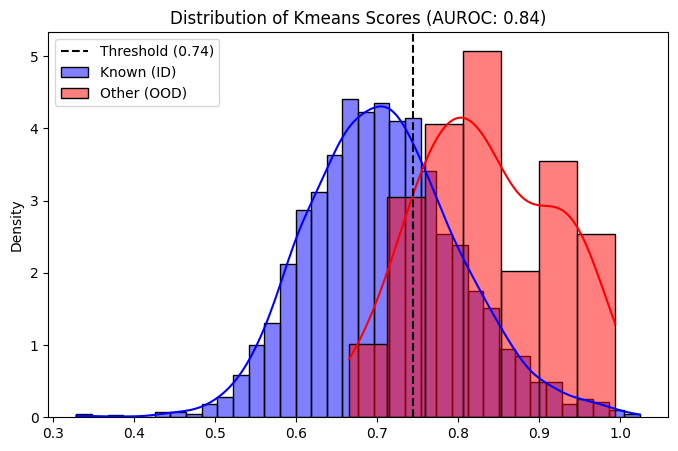


--- Results for Mahalanobis Scores ---
AUROC Score: 0.6850
Optimal Threshold (Youden): 17.6877


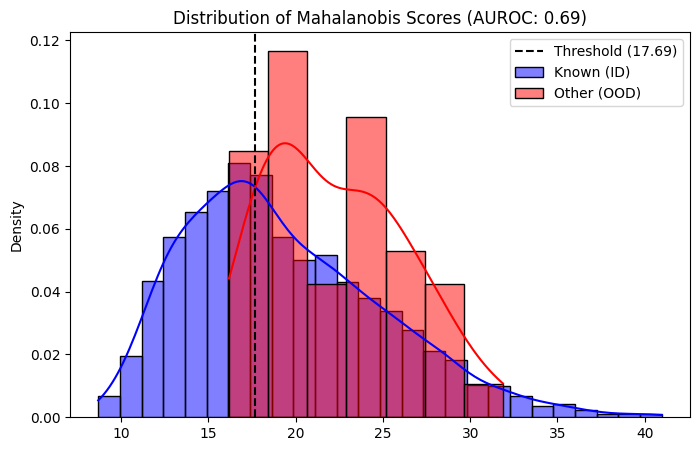


--- Results for Cosine Scores ---
AUROC Score: 0.7833
Optimal Threshold (Youden): 0.3903


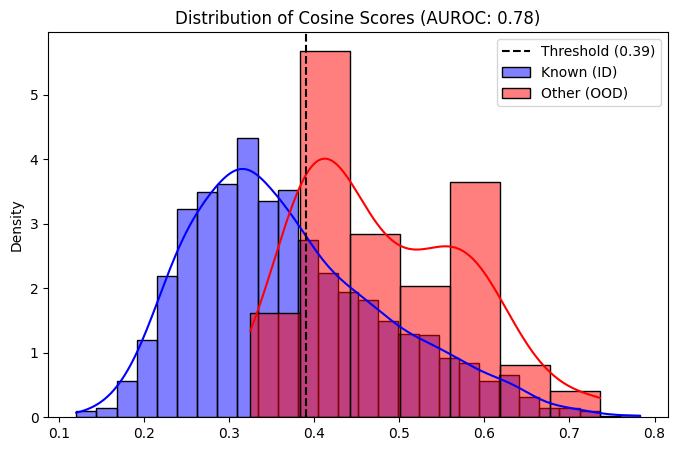

In [12]:
scoring_methods = {
    'kmeans': {'id': kmeans_scores_id, 'ood': kmeans_scores_ood},
    'mahalanobis': {'id': mahalanobis_scores_id, 'ood': mahalanobis_scores_ood},
    'cosine': {'id': cosine_scores_id, 'ood': cosine_scores_ood},
}

# Dictionary to store optimal thresholds for each method
optimal_thresholds = {}

for method_name, scores in scoring_methods.items():
    print(f"\n--- Results for {method_name.capitalize()} Scores ---")

    # 1. Create labels for test data (0 = ID, 1 = OOD)
    y_true_id = np.zeros(len(scores['id']))
    y_true_ood = np.ones(len(scores['ood']))

    y_true = np.concatenate([y_true_id, y_true_ood])
    y_scores = np.concatenate([scores['id'], scores['ood']])

    # 2. Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    print(f"AUROC Score: {auc_score:.4f}")

    # 3. Find optimal threshold (Youden's J Statistic)
    # This is the point that maximizes the sum of sensitivity (TPR) and specificity (1-FPR).
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    optimal_thresholds[method_name] = best_thresh # Store the optimal threshold

    print(f"Optimal Threshold (Youden): {best_thresh:.4f}")

    # Optional: Plot to see how good the separation is
    plt.figure(figsize=(8, 5))
    sns.histplot(scores['id'], color='blue', label='Known (ID)', kde=True, stat="density", alpha=0.5)
    sns.histplot(scores['ood'], color='red', label='Other (OOD)', kde=True, stat="density", alpha=0.5)
    plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
    plt.title(f"Distribution of {method_name.capitalize()} Scores (AUROC: {auc_score:.2f})")
    plt.legend()
    plt.show()



Validation for Method: Kmeans
Calculating OOD scores for df_validate with method: kmeans...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.67      0.33      0.44       279
 OOD (Other)       0.62      0.87      0.72       344

    accuracy                           0.63       623
   macro avg       0.64      0.60      0.58       623
weighted avg       0.64      0.63      0.60       623



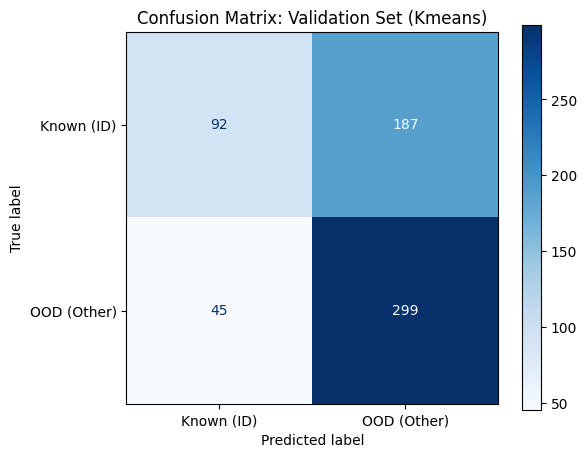

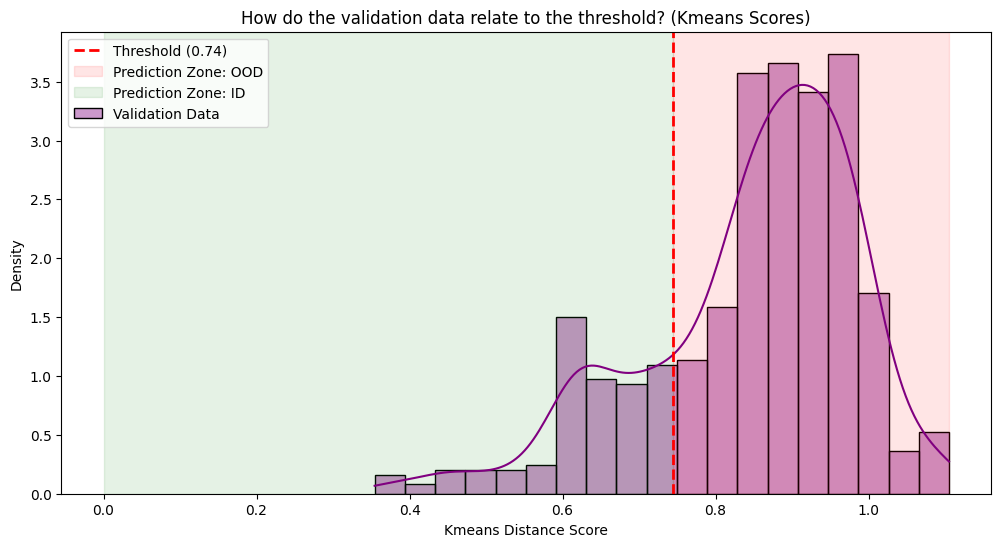


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
349,"AVP, Dental Quality & Clinical Oversight",Other,1.105110,OOD (Other)
126,Physiotherapeutin,Other,1.094508,OOD (Other)
463,Radio Engineering @ TDI | Huawei SRAN & Mobile...,Information Technology,1.091277,OOD (Other)
53,Head of aws Preseed and Seedfinancing - Innova...,Other,1.088940,OOD (Other)
414,Sports Columnist,Other,1.088451,OOD (Other)
472,Set Lighting,Other,1.086639,OOD (Other)
573,Set Lighting,Other,1.086639,OOD (Other)
9,Set Lighting,Other,1.086639,OOD (Other)
606,Set Lighting,Other,1.086639,OOD (Other)
593,Set Lighting,Other,1.086639,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
536,Assistent der Geschäftsleitung,Administrative,0.354347,Known (ID)
326,Projektleiter,Project Management,0.377256,Known (ID)
519,Projektleiter,Project Management,0.377256,Known (ID)
273,SAP Solutions Consultant,Consulting,0.382682,Known (ID)
253,Project Manager,Project Management,0.430232,Known (ID)
72,Project Manager,Project Management,0.430232,Known (ID)
37,Business Development Manager,Business Development,0.436480,Known (ID)
221,HR-Manager,Human Resources,0.443653,Known (ID)
56,Projektmanager,Project Management,0.449300,Known (ID)
10,Projektmanager,Project Management,0.449300,Known (ID)




Validation for Method: Mahalanobis
Calculating OOD scores for df_validate with method: mahalanobis...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.90      0.16      0.27       279
 OOD (Other)       0.59      0.99      0.74       344

    accuracy                           0.62       623
   macro avg       0.75      0.57      0.51       623
weighted avg       0.73      0.62      0.53       623



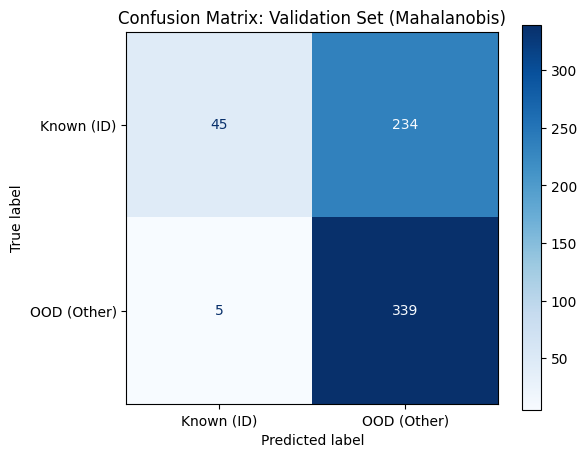

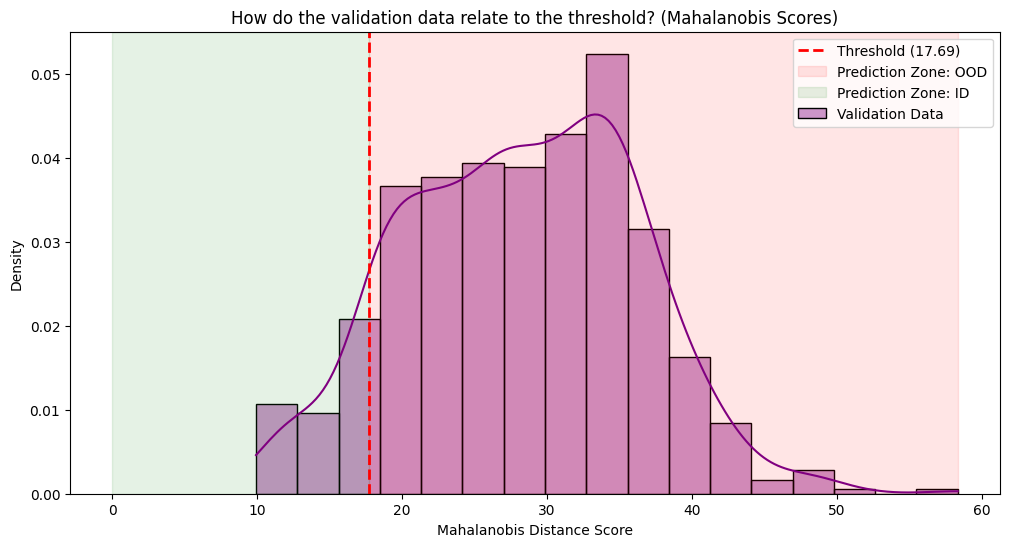


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
269,49504,Other,58.324401,OOD (Other)
348,Dozent,Other,50.788603,OOD (Other)
573,Set Lighting,Other,48.214829,OOD (Other)
472,Set Lighting,Other,48.214829,OOD (Other)
593,Set Lighting,Other,48.214829,OOD (Other)
606,Set Lighting,Other,48.214829,OOD (Other)
9,Set Lighting,Other,48.214829,OOD (Other)
126,Physiotherapeutin,Other,46.161518,OOD (Other)
146,Dozent/ Ausbilder,Other,45.791101,OOD (Other)
227,Ruby Fullstack Developer,Information Technology,44.566070,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
37,Business Development Manager,Business Development,9.914107,Known (ID)
59,Digital Marketing Manager,Marketing,10.458614,Known (ID)
15,Senior Project Manager,Project Management,11.098685,Known (ID)
25,Senior Project Manager,Project Management,11.098685,Known (ID)
56,Projektmanager,Project Management,11.341067,Known (ID)
10,Projektmanager,Project Management,11.341067,Known (ID)
480,Projektmanager,Project Management,11.341067,Known (ID)
34,Director Sales,Sales,11.498302,Known (ID)
285,Head of Sales DACH,Sales,11.540315,Known (ID)
300,Director of Sales & Marketing,Sales,11.674165,Known (ID)




Validation for Method: Cosine
Calculating OOD scores for df_validate with method: cosine...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

  Known (ID)       0.60      0.28      0.38       279
 OOD (Other)       0.59      0.85      0.70       344

    accuracy                           0.59       623
   macro avg       0.59      0.56      0.54       623
weighted avg       0.59      0.59      0.55       623



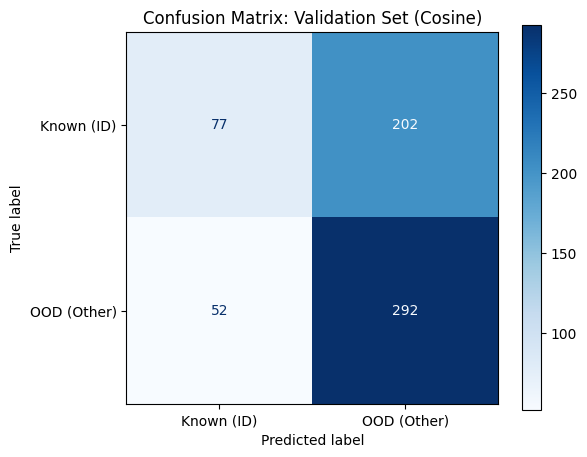

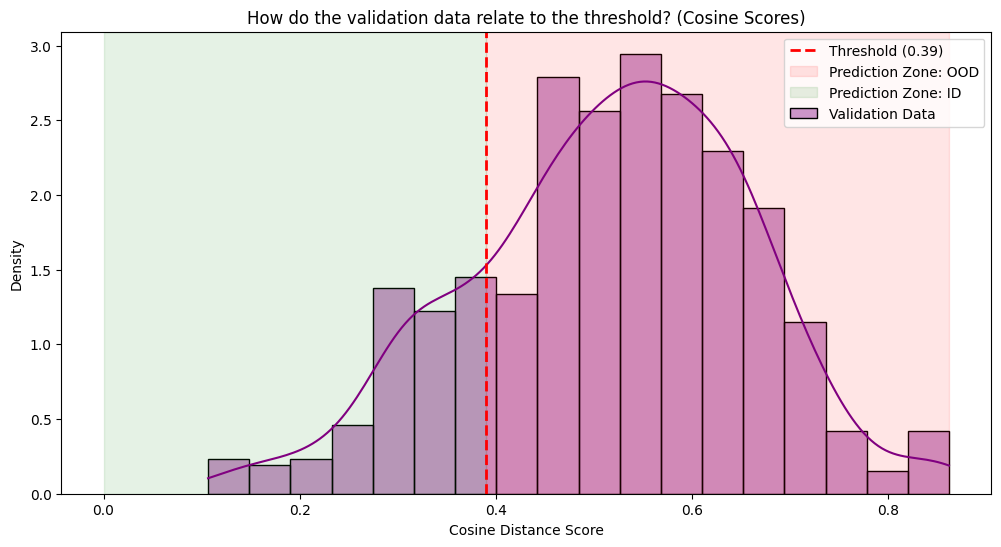


--- Examples: Recognized as OOD (Top Scores) ---


,text,label,ood_score,prediction
41,iş güvenliği,Other,0.861980,OOD (Other)
9,Set Lighting,Other,0.857178,OOD (Other)
573,Set Lighting,Other,0.857178,OOD (Other)
593,Set Lighting,Other,0.857178,OOD (Other)
606,Set Lighting,Other,0.857178,OOD (Other)
472,Set Lighting,Other,0.857178,OOD (Other)
349,"AVP, Dental Quality & Clinical Oversight",Other,0.852082,OOD (Other)
463,Radio Engineering @ TDI | Huawei SRAN & Mobile...,Information Technology,0.848714,OOD (Other)
269,49504,Other,0.828672,OOD (Other)
126,Physiotherapeutin,Other,0.828320,OOD (Other)



--- Examples: Recognized as ID (Lowest Scores - very confident) ---


,text,label,ood_score,prediction
37,Business Development Manager,Business Development,0.106586,Known (ID)
221,HR-Manager,Human Resources,0.109236,Known (ID)
433,Consultant,Consulting,0.132395,Known (ID)
56,Projektmanager,Project Management,0.145955,Known (ID)
480,Projektmanager,Project Management,0.145955,Known (ID)
10,Projektmanager,Project Management,0.145955,Known (ID)
536,Assistent der Geschäftsleitung,Administrative,0.154611,Known (ID)
151,Business Consultant,Consulting,0.161212,Known (ID)
275,Senior Consultant,Consulting,0.171290,Known (ID)
449,Business Development Leader,Business Development,0.178316,Known (ID)


In [13]:
# List of scoring methods to validate
validation_methods_to_run = ['kmeans', 'mahalanobis', 'cosine']

for VALIDATION_METHOD in validation_methods_to_run:
    print(f"\n\n=======================================================")
    print(f"Validation for Method: {VALIDATION_METHOD.capitalize()}")
    print(f"=======================================================")

    # 1. Calculate scores for validation data
    print(f"Calculating OOD scores for df_validate with method: {VALIDATION_METHOD}...")
    val_scores = get_ood_scores(val_embeddings, VALIDATION_METHOD )

    # Retrieve the best threshold for the selected method
    best_thresh_for_validation = optimal_thresholds.get(VALIDATION_METHOD)

    if best_thresh_for_validation is None:
        print(f"Error: No optimal threshold found for method '{VALIDATION_METHOD}'. Please run the previous cell first to calculate thresholds.")
        continue # Skip to the next method if threshold is missing

    # Write results to a copy
    df_val_results = df_validate.copy()
    df_val_results['ood_score'] = val_scores

    # 2. Prediction based on your threshold-
    # Everything above the threshold is "OOD" (i.e., "Other"), everything below is "ID" (Known)
    df_val_results['prediction'] = df_val_results['ood_score'].apply(
        lambda x: 'OOD (Other)' if x > best_thresh_for_validation else 'Known (ID)'
    )

    # Calculate uncertainty (distance to threshold)
    df_val_results['distance_to_threshold'] = df_val_results['ood_score'] - best_thresh_for_validation

    # 3. Ground Truth Comparison (if labels are available)
    # We assume your label 'Other' is the target for OOD.
    LABEL_COL = 'label'
    OOD_CLASS_NAME = 'Other' # As it appears in the dataset

    if LABEL_COL in df_val_results.columns:
        # Create binary labels for evaluation (1 = OOD, 0 = ID)
        y_true_val = (df_val_results[LABEL_COL] == OOD_CLASS_NAME).astype(int)
        y_pred_val = (df_val_results['prediction'] == 'OOD (Other)').astype(int)

        print("\n--- Classification Report (Validation Set) ---")
        print(classification_report(y_true_val, y_pred_val, target_names=['Known (ID)', 'OOD (Other)']))

        # Confusion Matrix Plot
        cm = confusion_matrix(y_true_val, y_pred_val)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Known (ID)', 'OOD (Other)'])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(cmap='Blues', ax=ax)
        plt.title(f"Confusion Matrix: Validation Set ({VALIDATION_METHOD.capitalize()})")
        plt.show()

    # 4. Visualization of Score Distribution-
    plt.figure(figsize=(12, 6))

    # Histogram of Validation Scores
    sns.histplot(
        df_val_results['ood_score'],
        color='purple',
        label='Validation Data',
        kde=True,
        stat="density",
        alpha=0.4
    )

    # Threshold Line
    plt.axvline(best_thresh_for_validation, color='red', linestyle='--', linewidth=2, label=f'Threshold ({best_thresh_for_validation:.2f})')

    # Color areas
    plt.axvspan(best_thresh_for_validation, df_val_results['ood_score'].max(), color='red', alpha=0.1, label='Prediction Zone: OOD')
    plt.axvspan(0, best_thresh_for_validation, color='green', alpha=0.1, label='Prediction Zone: ID')

    plt.title(f"How do the validation data relate to the threshold? ({VALIDATION_METHOD.capitalize()} Scores)")
    plt.xlabel(f"{VALIDATION_METHOD.capitalize()} Distance Score")
    plt.legend()
    plt.show()

    print("\n--- Examples: Recognized as OOD (Top Scores) ---")
    ood_detected = df_val_results[df_val_results['prediction'] == 'OOD (Other)'].sort_values('ood_score', ascending=False)
    display(ood_detected[['text', LABEL_COL, 'ood_score', 'prediction']].head(10))

    print("\n--- Examples: Recognized as ID (Lowest Scores - very confident) ---")
    id_detected = df_val_results[df_val_results['prediction'] == 'Known (ID)'].sort_values('ood_score', ascending=True)
    display(id_detected[['text', LABEL_COL, 'ood_score', 'prediction']].head(10))